In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind, t, sem, wilcoxon
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
import matplotlib.colors as mcolors
from scipy import stats

cm = 1/2.54  # inches to cm

def p_to_star(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

gray_to_red = mcolors.LinearSegmentedColormap.from_list("gray_to_red", [(0.5, 0.5, 0.5), (1, 0, 0)])

In [2]:
adata_sigma = sc.read_h5ad("/mnt/projects_tn03/Data_MK/article/results_fortman/merge.h5ad")
adata_author = sc.read_h5ad("/mnt/scratch/guillaume/plt_covid_eric/fortmann/BloodAdvances_COVID_Megakaryocytes.h5ad")

adata_sigma.obs_names = [re.sub(r"-Blood.*", "", name) for name in adata_sigma.obs_names]

In [3]:
adata_sumry = ad.AnnData(adata_author.layers["counts"], var=adata_author.var)
adata_sumry.obs_names = adata_author.obs_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]

# Add obs table
adata_sumry.obs["donor"] = adata_author.obs["sample"]
adata_sumry.obs["phase"] = adata_author.obs["phase"]
adata_sumry.obs["dataset"] = adata_author.obs["dataset"]
adata_sumry.obs["celltype"] = adata_author.obs["clusters"]
adata_sumry.obs["disease"] = adata_author.obs["disease"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry.layers["log1p"] = adata_sumry.X

# Score plot

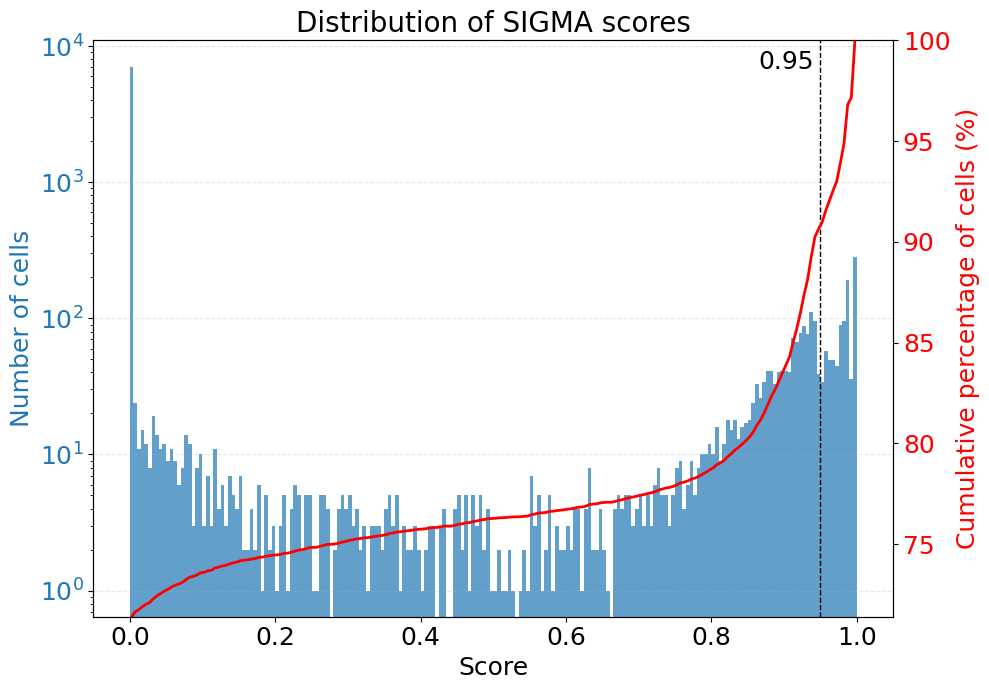

In [4]:
seuil = 0.95

fig, ax1 = plt.subplots(figsize=(10,7))

# Histogramme
n, bins, patches = ax1.hist(adata_sigma.obs["score"], bins=200, alpha=0.7, label='Count')
ax1.set_xlabel("Score")
ax1.set_ylabel("Number of cells", color='C0')
ax1.set_yscale("log")
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Somme cumulée sur un second axe
ax2 = ax1.twinx()
cumsum_pct = 100 * np.cumsum(n) / np.sum(n)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax2.plot(bin_centers, cumsum_pct, color='red', linewidth=2, label='Cumulative %')
ax2.set_ylabel("Cumulative percentage of cells (%)", color='red')
ax2.set_ylim(min(cumsum_pct), 100)
ax2.tick_params(axis='y', labelcolor='red')

# Ligne verticale pour le seuil
ax1.axvline(seuil, color='black', linestyle='--', linewidth=1)
ax1.text(seuil-0.085, ax1.get_ylim()[1]*0.85, str(seuil), color='black', ha='left', va='top', fontsize=18)
ax1.set_title("Distribution of SIGMA scores")

ax1.tick_params(axis="both", labelsize=18)
ax2.tick_params(axis="y", labelsize=18)
ax1.xaxis.label.set_size(18)
ax1.yaxis.label.set_size(18)
ax2.yaxis.label.set_size(18)
ax1.title.set_size(20)

fig.tight_layout()
fig.savefig("figures/fortmann_Score_cumulative.svg", bbox_inches="tight", dpi=500)
plt.show()

# MK : 928
% among all cells : 0.292 %


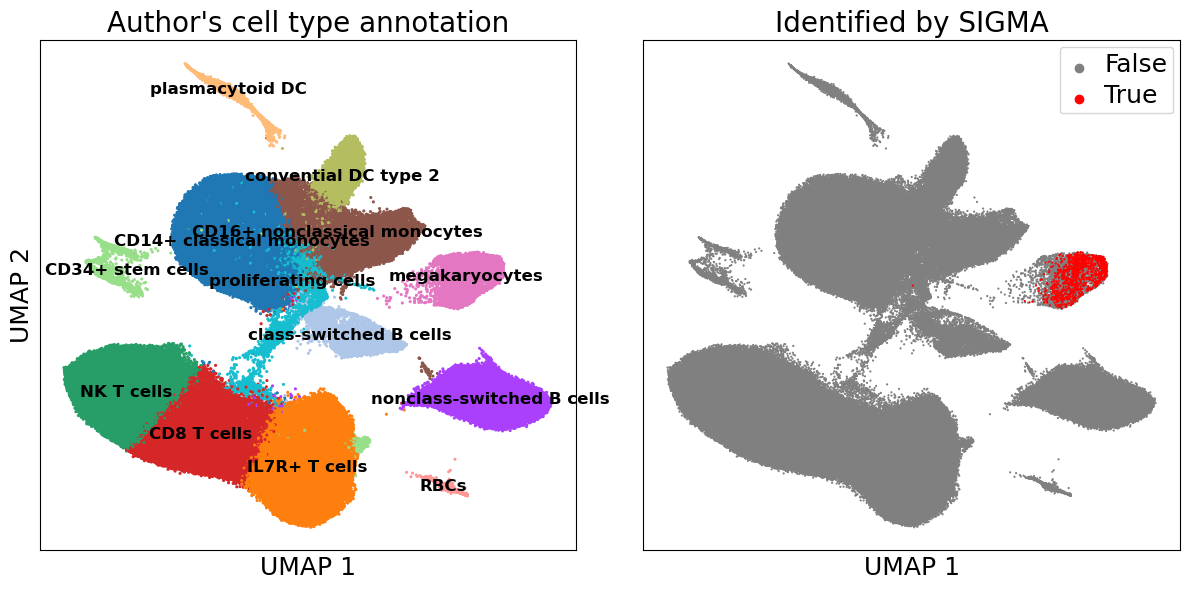

In [5]:
MK_found_by_sigma = adata_sumry.obs["score"] >= seuil
adata_sumry.obs["Identified by SIGMA"] = MK_found_by_sigma.astype(str)
adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(adata_sumry.obs["Identified by SIGMA"],
                                                        categories=["False", "True"], ordered=True)

print(f"# MK : {np.sum(MK_found_by_sigma)}")
print(f"% among all cells : {np.sum(MK_found_by_sigma)/adata_sumry.n_obs*100:.3f} %")

adata_sumry.uns["Identified by SIGMA_colors"] = ["#808080", "#ff0000"]

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

sc.pl.umap(adata_sumry, s=20, title="Author's cell type annotation", color="celltype",
           ax=ax[0], legend_loc="on data", legend_fontsize=12, show=False)

sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "False"], s=10, 
           title="MK identified by SIGMA", color="Identified by SIGMA", ax=ax[1], legend_loc=None, show=False)

sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"], s=10, 
           color="Identified by SIGMA", ax=ax[1], legend_loc=None, show=False)

sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] != "none"], s=0, 
           color="Identified by SIGMA", ax=ax[1], legend_loc="upper right", show=False)


for idx, a in enumerate(ax):
    a.set_xlabel("UMAP 1")
    a.set_ylabel("UMAP 2")
    if a.get_legend() is not None:
        a.set_ylabel(None)
        a.get_legend().set_title(a.get_legend().get_title().get_text(), prop={"size": 16})
        for text in a.get_legend().get_texts():
            text.set_fontsize(18)
    a.tick_params(labelbottom=False, labelleft=False)
    a.set_xticklabels([])
    a.set_yticklabels([])
    a.xaxis.label.set_size(18)
    a.yaxis.label.set_size(18)
    a.title.set_size(20)

plt.tight_layout()
fig.savefig("figures/fortman_SIGMAvsCLUSTER.tiff", bbox_inches='tight', dpi=500)
plt.show()

# Why author's MK are not found by SIGMA

In [6]:
mk_author = adata_sumry[adata_sumry.obs["celltype"] == "megakaryocytes"]

print(f"% among megakaryocytes' authors : {np.sum(MK_found_by_sigma)/mk_author.n_obs:.3%}")

% among megakaryocytes' authors : 22.201%


In [7]:
mk_mature = ['ITGB3', 'FCGR2A', 'CD40LG', 'ITGA2B', 'GP1BA', 'PF4', 'GP6', 'PPBP']
mono = ['S100A12', 'LST1', 'LGALS3', 'VCAN', 'S100A9', 'S100A8', 'FCGR3A', 'CTSS', 'CD14']
macro = ['FCGR1A', 'MRC1', 'CSF1R', 'CX3CR1', 'CCR2', 'CD163', 'AIF1', 'CD14', 'CD68', 'LYZ']
Tlympho = ['CD8B', 'CD3E', 'TRAC', 'CD4', 'CD3D', 'CD3G', 'CD8A']
Blympho = ['MS4A1', 'CD19', 'HLA-DRA', 'CD79B', 'PAX5', 'CD74', 'HLA-DQB1', 'CD79A']
neutro = ['S100A12', 'FCGR3B', 'LCN2', 'ELANE', 'S100A9', 'S100A8', 'CEACAM8', 'CXCL8', 'MPO', 'CTSG', 'PRTN3']

mk_df = mk_author.to_df()
mk_df["identified"] = mk_author.obs["Identified by SIGMA"].values
mk_df["disease"] = mk_author.obs["disease"].values
mk_df = mk_df[mk_df["disease"].isin(["covid", "healthy"])]
mk_df["disease"] = mk_df["disease"].astype(str)

mk_df_melt = mk_df.melt(
    id_vars=["identified", "disease"],
    var_name="gene",
    value_name="expression"
)

/tmp/ipykernel_2123871/3798909319.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2123871/3798909319.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
/tmp/ipykernel_2123871/3798909319.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
/tmp/ipykernel_2123871/3798909319.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
/tmp/ipyke

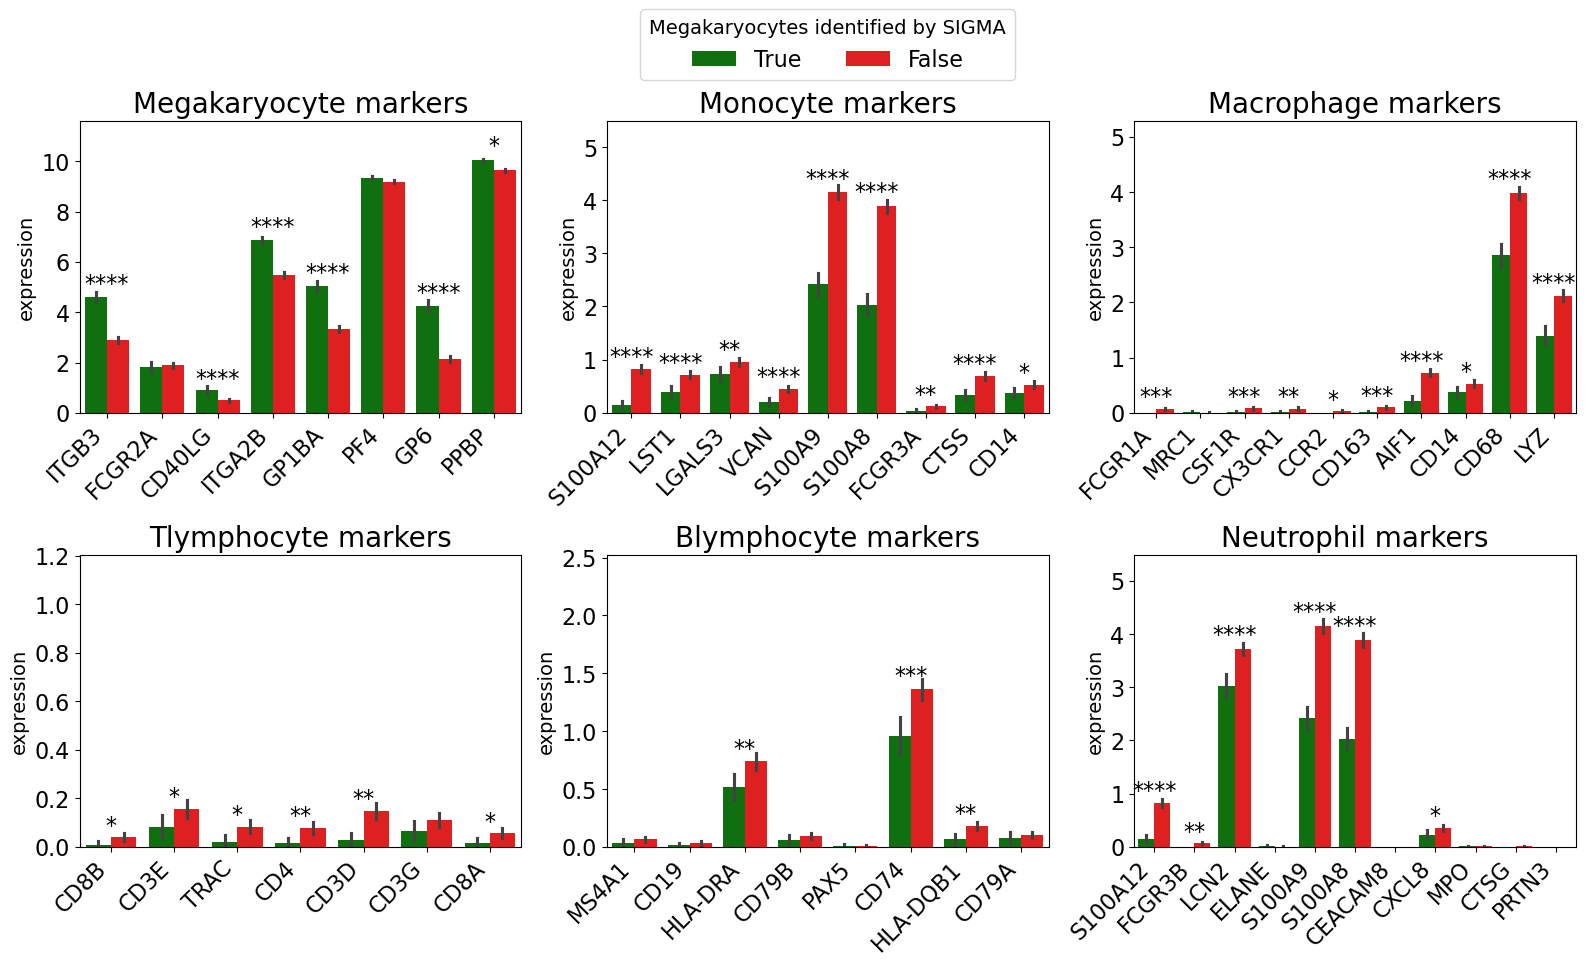

In [8]:
fig, ax = plt.subplots(2,3,figsize=(16, 10))
ax = ax.flatten()
cpt = 0

for gene_chosen in {"Megakaryocyte markers":mk_mature, "Monocyte markers":mono, "Macrophage markers":macro, "Tlymphocyte markers":Tlympho, "Blymphocyte markers":Blympho, "Neutrophil markers":neutro}.items():

    df = mk_df_melt.loc[mk_df_melt["gene"].isin(gene_chosen[1]), ["gene", "identified", "expression"]].copy()
    df = df.dropna(subset=["expression"]).copy()
    df["identified"] = df["identified"].eq("True")

    mannwhit_res = {}
    for gene, sub in df.groupby("gene", sort=False):
        no_ident = sub.loc[~sub["identified"], "expression"].to_numpy()
        ident = sub.loc[sub["identified"],  "expression"].to_numpy()
        U, p = mannwhitneyu(no_ident, ident, alternative="less" if gene_chosen[0] == "Megakaryocyte markers" else "greater")
        mannwhit_res[gene] = (U, p)

    mannwhit_df = (
        pd.DataFrame.from_dict(mannwhit_res, orient="index", columns=["U_stat", "p_value"])
        .rename_axis("gene").reset_index()
        )
    mannwhit_df["p_value_adj"] = multipletests(mannwhit_df["p_value"], method="fdr_bh")[1]

    plot_df = df.assign(identified=df["identified"].map({False: "False", True: "True"}))

    sns.barplot(data=plot_df,
        x="gene", y="expression", hue="identified",
        order=gene_chosen[1], ax=ax[cpt], 
        palette={"False": "red", "True": "green"}, 
    )

    bar_top = plot_df.groupby(["gene", "identified"])["expression"].mean().groupby("gene").max()

    for i, gene in enumerate(gene_chosen[1]):
        pval = mannwhit_df.loc[mannwhit_df["gene"] == gene,"p_value_adj"].values

        y0 = float(bar_top.loc[gene])
        pad = 0.01 * y0

        ax[cpt].text(
            i, y0 + pad,
            p_to_star(pval),
            ha="center", va="bottom", fontsize=16
        )

    ax[cpt].set_ylim(0, ax[cpt].get_ylim()[1]+1)
    ax[cpt].set_xlabel(None)
    ax[cpt].yaxis.label.set_size(14)
    ax[cpt].set_title(f"{gene_chosen[0]}", fontsize=20)
    ax[cpt].set_yticklabels(ax[cpt].get_yticklabels(), fontsize=16)
    ax[cpt].set_xticklabels(ax[cpt].get_xticklabels(), rotation=45, ha="right", fontsize=16)
    if cpt == 1:
        ax[cpt].legend(title="Megakaryocytes identified by SIGMA", bbox_to_anchor=(0.5, 1.42), 
                       loc="upper center", ncol=2, fontsize=16, title_fontsize=14)
    else:
        ax[cpt].get_legend().remove()
    cpt += 1

plt.tight_layout()
fig.savefig("figures/fortmann_LineageExpression.svg", bbox_inches="tight", dpi=500)
plt.show()

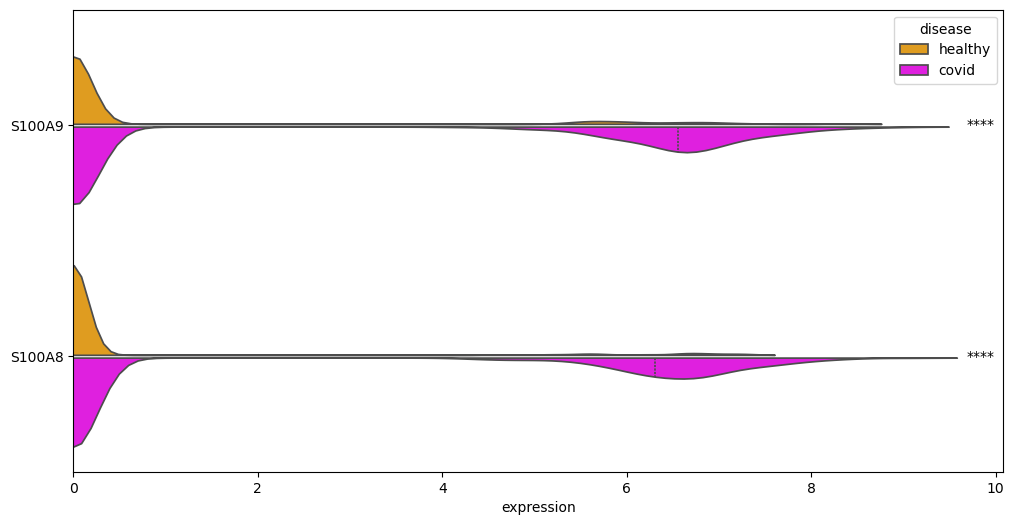

In [9]:
mk_df_melt_s100 = mk_df_melt[mk_df_melt["gene"].isin(["S100A8", "S100A9"])]
mk_df_melt_s100 = mk_df_melt_s100[mk_df_melt_s100["disease"].isin(["covid", "healthy"])]
mk_df_melt_s100 = mk_df_melt_s100[mk_df_melt_s100["identified"] == "True"]

# Mann-Whitney test between covid and healthy for each gene in mk_df_melt_s100
pvals_covid_healthy = {}

for gene, sub in mk_df_melt_s100.groupby("gene"):
    x = sub.loc[sub["disease"] == "covid", "expression"]
    y = sub.loc[sub["disease"] == "healthy", "expression"]
    _, p = mannwhitneyu(x, y, alternative="greater")
    pvals_covid_healthy[gene] = p

fig, ax = plt.subplots(figsize=(12, 6))
ax = sns.violinplot(data=mk_df_melt_s100,
    y="gene", x="expression", hue="disease",
    palette={"covid": "magenta", "healthy": "orange"},
    split=True, gap=0.03, inner="quart", bw_adjust=0.3
)

y_order = [t.get_text() for t in ax.get_yticklabels()]
x_min, x_max = 0, ax.get_xlim()[-1]
ax.set_xlim(x_min, x_max)
ax.set_ylabel(None)

for i, gene in enumerate(y_order):
    p = pvals_covid_healthy.get(gene)
    star = p_to_star(p)
    ax.text(x_max-0.4, i, star, va="center", ha="left", fontsize=10)

fig.savefig("figures/fortmann_S100A8-9.svg", bbox_inches="tight", dpi=500)
plt.show()